In [44]:
import polars as pl
import os

import sys
sys.path.append('..')
from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()
import numpy as np
import json
from skimage.measure import label

from skimage import measure

from src import IOFunctions; IO = IOFunctions.IO_Functions()

import matplotlib.pyplot as plt

from src import AnalysisFunctions; A_F = AnalysisFunctions.Analysis_Functions()

from src import CoincidenceFunctions; C_F = CoincidenceFunctions.Coincidence_Functions()

In [45]:
cingulate_PD_region = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots'

In [46]:
files = os.listdir(cingulate_PD_region)
files = np.sort([x for x in files if '.csv' in x])
files = np.sort([x for x in files if 'images_' in x])

In [47]:
files

array(['images_C030_HC.csv', 'images_C043_HC.csv', 'images_C074_HC.csv',
       'images_PD0086_PD.csv', 'images_PD0612_PD.csv',
       'images_PD0913_PD.csv', 'images_PD0917_PD.csv',
       'images_PD0945_PD.csv'], dtype='<U20')

In [48]:
PD_patients =  ['PD0086',  'PD0945', 'PD0612', 'PD0913', 'PD0917']
HC_patients =  ['C030', 'C064', 'C036', 'C043', 'C049', 'C074']

In [49]:
def file_selector(folder, oligomer_data, percentile=20):
    files = os.listdir(folder)
    file = np.sort([x for x in files if 'percentile' in x and '_'+str(int(percentile))+'_' in x and '3Danalysis' in x])[0]
    data = pl.read_csv(os.path.join(folder, file))
    photonthreshold = float(file.split('_photonthreshold_')[1].split('_photons_')[0].replace('p', '.'))
    oligomer_data = oligomer_data.filter(pl.col('sum_intensity_in_photons') < 3000)
    percentile = oligomer_data['sum_intensity_in_photons'].rank()/len(oligomer_data['sum_intensity_in_photons'])
    oligomer_data = oligomer_data.with_columns(percentile.alias("alpha"))
    return oligomer_data

In [120]:
raw_data_region = '/scratch/sycamore-asap/ASAP_Imaging_Data/Main_Survey/20241105_oligomers_in_cells/cingulate/microglia/PD_analysis'
cingulate_PD_data = pl.read_csv(os.path.join(raw_data_region, 'spot_analysis.csv'))
cingulate_PD_data = file_selector(raw_data_region, cingulate_PD_data, percentile=90)

In [121]:
filenames = np.unique(cingulate_PD_data['image_filename'].to_numpy())

In [122]:
PD1_microglia_files = pl.read_csv(os.path.join(cingulate_PD_region, files[3]))
PD1_microglia_files = PD1_microglia_files.filter(pl.col('cell_type') == 'microglia').filter(pl.col('region') == 'cingulate')

In [123]:
specific_files = [x.split('\\')[-1].split('.tif')[0] for x in np.unique(PD1_microglia_files['image_filename']) if '.tif' in x]
filenames = []
for fname in specific_files:
    filenames = np.hstack([filenames, np.unique([x for x in cingulate_PD_data['image_filename'].to_numpy() if fname in x])])

In [54]:
def quick_plotter(filename, oligomer_data=None, protein_string='C1',
                                       cell_string='C0', xmin=0, 
                                       xmax=1200, ymin=0, ymax=1200, zplane=None, labelval=None, 
                                       alpha_threshold=0.0, show_oligomers=False,
                 scalebarsize=10000, scalebarlabel='10 µm'):
    """
    Plot cell mask with optional oligomer overlay and return oligomers inside selected cell.
    
    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomer_data : polars.DataFrame, optional
        DataFrame containing oligomer data with columns: image_filename, x, y, alpha, zi, zf
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for plotting
    zplane : int, optional
        Specific z-plane to show for protein (if None, uses MIP)
    labelval : int, optional
        Specific label value to plot. If None, plots all labels separately
    alpha_threshold : float
        Minimum alpha value for oligomer filtering (default 0.0)
    show_oligomers : bool
        Whether to overlay oligomer positions on the plot (default False)
        
    Returns:
    --------
    oligomers_in_cell : polars.DataFrame or None
        Filtered oligomers inside the selected label (only when labelval is specified and oligomer_data provided)
    """
    raw_protein_image = IO.read_tiff_tophotons(filename)
    analysis_folder = os.path.split(os.path.split(filename)[0])[0]+"_analysis"

    cell_filename = filename.split(protein_string+'.tif')[0]+cell_string+'.tif'
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)
    cell_MIP = np.max(raw_cell_image, axis=0)
    
    if zplane is not None:
        protein_MIP = raw_protein_image[zplane, : , :]
    else:
        protein_MIP = np.max(raw_protein_image, axis=0)
    
    cell_mask_string = os.path.split(filename)[-1].split(protein_string+'.tif')[0]+cell_string+'_cellMask_cleanedup.tiff'
    cell_mask = IO.read_tiff(os.path.join(analysis_folder, cell_mask_string))
    labeled_image = label(cell_mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)
    
    oligomers_in_cell = None
    
    if labelval is not None:
        fig, axs = plotter.one_column_plot()
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1
        
        # Filter oligomers if data provided
        if oligomer_data is not None:
            # Get oligomers for this image
            oligomers = oligomer_data.filter(pl.col('image_filename') == filename)
            oligomers = oligomers.filter(pl.col("alpha") >= alpha_threshold)
            
            if len(oligomers) > 0:
                x = oligomers['x'].to_numpy()
                y = oligomers['y'].to_numpy()
                alpha = oligomers['alpha'].to_numpy()
                
                # Generate indices for mask and spots
                centroids = np.vstack([np.array(x, dtype=int), np.array(y, dtype=int)]).T
                mask_indices = A_F.generate_indices(np.array(mask_toplot_filtered, dtype=bool), (1200, 1200), is_mask=True)
                spot_indices = A_F.generate_indices(centroids, (1200, 1200))
                spot_indices = C_F._apply_blur(spot_indices, (1200, 1200), 1)
                
                # Test which oligomers are inside the cell
                in_cell = C_F.test_spot_spot_overlap(spot_indices, mask_indices, n_spot1=len(x), raw=True)
                
                # Filter oligomers
                oligomers_in_cell = oligomers.filter(pl.lit(in_cell))
                
                print(f"Found {len(oligomers_in_cell)} oligomers inside cell label {labelval}")
                print(f"  Total oligomers in image: {len(oligomers)}")
                print(f"  Percentage in cell: {100*len(oligomers_in_cell)/len(oligomers):.2f}%")
                
                # Optionally show oligomers on plot
                if show_oligomers and len(oligomers_in_cell) > 0:
                    x_in = oligomers_in_cell['x'].to_numpy()
                    y_in = oligomers_in_cell['y'].to_numpy()
                    alpha_in = oligomers_in_cell['alpha'].to_numpy()
                    
                    # Filter to plotting region
                    plot_indices = (x_in >= xmin) & (x_in < xmax) & (y_in >= ymin) & (y_in < ymax)
                    x_plot = x_in[plot_indices] - xmin
                    y_plot = y_in[plot_indices] - ymin
                    alpha_plot = alpha_in[plot_indices]
                    
                    axs[0] = plotter.image_scatter_plot(axs=axs[0], data=protein_MIP[xmin:xmax, ymin:ymax],
                                                        xdata=x_plot, ydata=y_plot, facecolor='red',
                                                        alpha_scatter=alpha_plot, s=10, lws=0,
                                        cbar='off', scalebarsize=scalebarsize, scalebarlabel=scalebarlabel)      
                    axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white")
                else:
                    axs[0] = plotter.image_plot(axs=axs[0], data=protein_MIP[xmin:xmax, ymin:ymax],
                                        cbar='off', scalebarsize=scalebarsize, scalebarlabel=scalebarlabel)      
                    axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white")
            else:
                print(f"No oligomers found in image with alpha >= {alpha_threshold}")
                axs[0] = plotter.image_plot(axs=axs[0], data=protein_MIP[xmin:xmax, ymin:ymax],
                                        cbar='off', scalebarsize=scalebarsize, scalebarlabel=scalebarlabel)      
                axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white")
        else:
            # No oligomer data provided, just plot the mask
            axs[0] = plotter.image_plot(axs=axs[0], data=protein_MIP[xmin:xmax, ymin:ymax],
                                        cbar='off', scalebarsize=scalebarsize, scalebarlabel=scalebarlabel)      
            axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white")
        
    else:
        # Plot all labels separately (original behavior)
        for value in np.arange(len(np.unique(mask_toplot))):
            fig, axs = plotter.one_column_plot()
            mask_toplot_filtered = mask_toplot.copy()
            mask_toplot_filtered[mask_toplot_filtered != value] = 0
            mask_toplot_filtered[mask_toplot_filtered == value] = 1
            axs[0] = plotter.image_plot(axs=axs[0], data=protein_MIP[xmin:xmax, ymin:ymax],
                                        cbar='off', scalebarsize=scalebarsize, scalebarlabel=scalebarlabel)      
            axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white")
            
    
    return fig, axs, oligomers_in_cell

20231018_MS_R3_S39_SS1 - Position 1 [9]_XY1697635386_Z00_T3_C1.tif
Found 35 oligomers inside cell label 1
  Total oligomers in image: 3901
  Percentage in cell: 0.90%


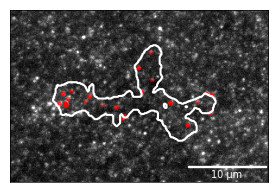


Oligomer data shape: (35, 11)

First few oligomers:
shape: (5, 11)
┌───────┬───────┬──────┬───────────────────────┬───┬─────┬──────┬───────────────────────┬──────────┐
│ y     ┆ x     ┆ z    ┆ sum_intensity_in_phot ┆ … ┆ zi  ┆ zf   ┆ image_filename        ┆ alpha    │
│ ---   ┆ ---   ┆ ---  ┆ ons                   ┆   ┆ --- ┆ ---  ┆ ---                   ┆ ---      │
│ f64   ┆ f64   ┆ f64  ┆ ---                   ┆   ┆ f64 ┆ f64  ┆ str                   ┆ f64      │
│       ┆       ┆      ┆ f64                   ┆   ┆     ┆      ┆                       ┆          │
╞═══════╪═══════╪══════╪═══════════════════════╪═══╪═════╪══════╪═══════════════════════╪══════════╡
│ 556.0 ┆ 166.0 ┆ 11.0 ┆ 392.26226             ┆ … ┆ 1.0 ┆ 25.0 ┆ /scratch/sycamore-asa ┆ 0.747864 │
│       ┆       ┆      ┆                       ┆   ┆     ┆      ┆ p/ASAP_Im…            ┆          │
│ 479.0 ┆ 173.0 ┆ 11.0 ┆ 372.803778            ┆ … ┆ 1.0 ┆ 25.0 ┆ /scratch/sycamore-asa ┆ 0.700272 │
│       ┆       ┆      

In [103]:
# Example usage of upgraded quick_plotter with oligomer filtering
folder_to_save = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots'

i = 3
file = filenames[i]
print(os.path.split(file)[-1])

# Call the upgraded function - it now returns the oligomers inside the selected cell
fig, axs, oligomers_in_selected_cell = quick_plotter(file, 
                                           oligomer_data=cingulate_HC_data,
                                           labelval=1, 
                                           xmin=100, xmax=300,
                                           ymin=350, ymax=650,
                                           alpha_threshold=0.4,
                                           show_oligomers=True)

plt.savefig(os.path.join(folder_to_save, 'Microglia_HC_COSMX.svg'), dpi=600, format='svg')
plt.show(block=False)
# Now you can access the filtered oligomer data
if oligomers_in_selected_cell is not None:
    print(f"\nOligomer data shape: {oligomers_in_selected_cell.shape}")
    print("\nFirst few oligomers:")
    print(oligomers_in_selected_cell.head())

In [113]:
oligomers_in_selected_cell[2]

y,x,z,sum_intensity_in_photons,bg_per_punctum,bg_per_pixel,incell,zi,zf,image_filename,alpha
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
407.0,191.0,11.0,404.132789,1307.29849,21.788308,0.0,1.0,25.0,"""/scratch/sycamore-asap/ASAP_Im…",0.773543


In [124]:
oligomer_zs = np.array([11, 16, 19])
oligomers_xmins = np.array([121,169,185])
oligomers_xmaxs = np.array([141,189,205])
oligomers_ymins = np.array([927,524,713])
oligomers_ymaxs = np.array([947,544,733])

In [115]:
def cell_oligomer_3panel_generator_rawoligomer(file, oligomer_data, folder_to_save, protein_string='C1',
                                       cell_string='C0', xmins=0, 
                                       xmaxs=1200, ymins=0, ymaxs=1200, zvals=22):
    mm = 1/25.4
    fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1,1,1], height=(170/3)*mm, width=180*mm)

    for i in np.arange(3):
        xmin = xmins[i]
        xmax = xmaxs[i]
        ymin = ymins[i]
        ymax = ymaxs[i]
        analysis_folder = os.path.split(os.path.split(file)[0])[0]+"_analysis"
    
        protein_data = IO.read_tiff_tophotons(file)[zvals[i], :, :]
        if i == 0:
            scalebarlabel=r'300 nm'
            scalebarsize=300
        else:
            scalebarlabel=r'300 nm'
            scalebarsize=300
        axs[i] = plotter.image_plot(axs=axs[i], data=protein_data[xmin:xmax, ymin:ymax],
                                            cbar='off', masklinewidth=0.5, scalebarlabel=scalebarlabel, scalebarsize=scalebarsize)        
    return fig, axs

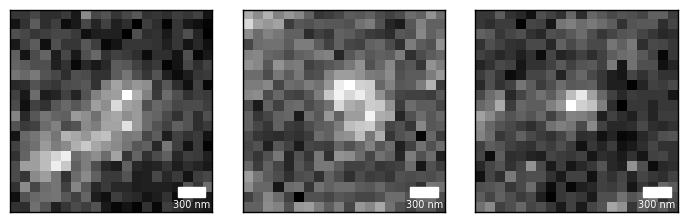

In [116]:
folder_to_save = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots'
fig, axs = cell_oligomer_3panel_generator_rawoligomer(file, cingulate_HC_data, folder_to_save, xmins=oligomers_xmins, 
                                                      xmaxs=oligomers_xmaxs, ymins=oligomers_ymins, ymaxs=oligomers_ymaxs, zvals=oligomer_zs)
plt.tight_layout()
plt.savefig(os.path.join(folder_to_save, 'Oligomers_in_HC_Microglia.svg'), format='svg', dpi=1200)


In [117]:
def cell_oligomer_context_panel(file, oligomer_xmins, oligomer_xmaxs, oligomer_ymins, oligomer_ymaxs,
                                labelval=None, protein_string='C1', cell_string='C0', 
                                xmin=0, xmax=1200, ymin=0, ymax=1200,
                                scalebarsize=10000, scalebarlabel='10 µm', label_boxes=True):
    """
    Create a single context panel showing where all three oligomer visualization regions are located.
    
    This function shows the same cell zoom as quick_plotter, with white boxes overlaid to indicate 
    the three zoomed-in regions shown in oligomer detail panels.
    
    Parameters:
    -----------
    file : str
        Path to the image file
    oligomer_xmins, oligomer_xmaxs, oligomer_ymins, oligomer_ymaxs : array-like
        Arrays of coordinates defining the zoomed oligomer regions (length 3)
    labelval : int, optional
        Specific cell label to highlight. If None, shows all cells
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for the cell view (same as used in quick_plotter)
    scalebarsize : int
        Size of scale bar in nm (default 10000)
    scalebarlabel : str
        Label for scale bar (default '10 µm')
    label_boxes : bool
        Whether to add numerical labels (1-3) to each box (default True)
        
    Returns:
    --------
    fig, axs : matplotlib figure and axes
    """
    mm = 1/25.4
    fig, axs = plotter.one_column_plot()
    
    # Load cell mask and images
    analysis_folder = os.path.split(os.path.split(file)[0])[0]+"_analysis"
    cell_filename = file.split(protein_string+'.tif')[0]+cell_string+'.tif'
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)
    cell_MIP = np.max(raw_cell_image, axis=0)
    
    # Load and label the cell mask
    cell_mask_string = os.path.split(file)[-1].split(protein_string+'.tif')[0]+cell_string+'_cellMask_cleanedup.tiff'
    cell_mask = IO.read_tiff(os.path.join(analysis_folder, cell_mask_string))
    labeled_image = label(cell_mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)
    
    # Filter to specific label if provided
    if labelval is not None:
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1
    else:
        mask_toplot_filtered = (mask_toplot > 0).astype(int)
    
    # Plot the cell image with mask contour (same view as quick_plotter)
    axs[0] = plotter.image_plot(axs=axs[0], 
                               data=cell_MIP[xmin:xmax, ymin:ymax],
                               cbar='off', 
                               masklinewidth=0.5, 
                               scalebarlabel=scalebarlabel, 
                               scalebarsize=scalebarsize)
    
    # Add mask contour
    axs[0].contour(mask_toplot_filtered[xmin:xmax, ymin:ymax], 
                  [0.5], lw=0.75, colors="white")
    
    # Draw all three white boxes showing oligomer regions
    from matplotlib.patches import Rectangle
    for i in np.arange(3):
        olig_xmin = oligomer_xmins[i]
        olig_xmax = oligomer_xmaxs[i]
        olig_ymin = oligomer_ymins[i]
        olig_ymax = oligomer_ymaxs[i]
        
        # Convert to coordinates relative to the cropped view
        rect = Rectangle((olig_ymin - ymin, olig_xmin - xmin), 
                        olig_ymax - olig_ymin, 
                        olig_xmax - olig_xmin,
                        linewidth=2, 
                        edgecolor='white', 
                        facecolor='none',
                        linestyle='--')
        axs[0].add_patch(rect)
        
        # Add numerical labels to boxes
        if label_boxes:
            # Position label at top-left corner of box with small offset
            axs[0].text(olig_ymin - ymin + 3, olig_xmin - xmin + 3, str(i+1), 
                       color='white', fontsize=10, weight='bold',
                       verticalalignment='top', horizontalalignment='left',
                       bbox=dict(boxstyle='square,pad=0.3', facecolor='black', 
                                edgecolor='white', linewidth=1, alpha=0.7))
    
    return fig, axs

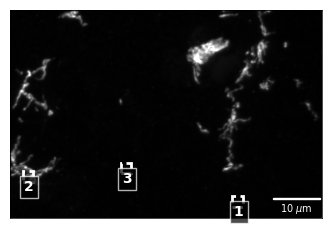

In [125]:
# Example: Create context panel showing where oligomer regions are located
# This shows ONE panel with the SAME zoom as quick_plotter, with THREE white boxes for oligomer regions
fig_context, axs_context = cell_oligomer_context_panel(
    file,
    oligomer_xmins=oligomers_xmins,  # The three oligomer box coordinates
    oligomer_xmaxs=oligomers_xmaxs, 
    oligomer_ymins=oligomers_ymins, 
    oligomer_ymaxs=oligomers_ymaxs,
    labelval=8,  # Same label as used in quick_plotter
    xmin=100, xmax=500,  # Same cell zoom bounds as quick_plotter
    ymin=500, ymax=1100,
    scalebarsize=10000,
    scalebarlabel=r'10 $\mu$m'
)
plt.tight_layout()
plt.savefig(os.path.join(folder_to_save, 'Oligomers_Context_PD_Neurons.svg'), format='svg', dpi=1200)
plt.show(block=False)